# <center>**Notebook P9**</center>

<div style="background-color: RGB(150, 20, 30);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

#Importation de la libraire Numpy
import numpy as np

#Importation de librairies pour faire des graphiques
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">1.2 - Chargement des fichiers</h3>
</div>

In [2]:
#attention aux anti-slash à mettre en slash dans le chemin d'accès pour ne pas avoir d'erreur

In [3]:
#Importation du fichier customers.csv
customers = pd.read_csv("D:/$27.12.2025 Ordinateur/$29.12.2025 Bureau/$GRETA/£P9/data/raw/customers.csv", sep=';', low_memory=False)
#'low_memory=False' permet d'exécuter le code avant de donner des types aux colonnes

#Importation du fichier products.csv
products = pd.read_csv("D:/$27.12.2025 Ordinateur/$29.12.2025 Bureau/$GRETA/£P9/data/raw/products.csv", sep=';', low_memory=False)

#Importation du fichier Transactions.csv
transactions = pd.read_csv("D:/$27.12.2025 Ordinateur/$29.12.2025 Bureau/$GRETA/£P9/data/raw/Transactions.csv", sep=';', low_memory=False)

<div style="background-color: RGB(150, 20, 30);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">2.1 - Analyse exploratoire du fichier 'customers.csv'</h3>
</div>

In [4]:
customers.head()

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


In [5]:
#fonction
#Il faut que le fichier mes_fonctions.py soit téléchargé au même emplacement que le notebook pour pouvoir importer la fonction
from mes_fonctions import inspector
inspector(customers)

#####     DEBUT DE L'INSPECTION     #####

----------------------
Structure du DataFrame:
Nb de lignes: 8621 ; Nb de colonnes: 3

----------------------
Types de données:
client_id    object
sex          object
birth         int64
dtype: object

----------------------
Nombre de valeurs uniques (pour identifiant PK / FK):
client_id    8621
sex             2
birth          76
dtype: int64

----------------------
Valeurs manquantes:
client_id    0
sex          0
birth        0
dtype: int64

#####     FIN DE L'INSPECTION     #####


<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">2.2 - Analyse exploratoire du fichier 'products.csv'</h3>
</div>

In [6]:
products.head()

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [7]:
from mes_fonctions import inspector
inspector(products)

#####     DEBUT DE L'INSPECTION     #####

----------------------
Structure du DataFrame:
Nb de lignes: 3286 ; Nb de colonnes: 3

----------------------
Types de données:
id_prod     object
price      float64
categ        int64
dtype: object

----------------------
Nombre de valeurs uniques (pour identifiant PK / FK):
id_prod    3286
price      1454
categ         3
dtype: int64

----------------------
Valeurs manquantes:
id_prod    0
price      0
categ      0
dtype: int64

#####     FIN DE L'INSPECTION     #####


<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">2.3 - Analyse exploratoire du fichier 'transactions.csv'</h3>
</div>

In [8]:
transactions.head()

,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


In [9]:
from mes_fonctions import inspector
inspector(transactions)

#####     DEBUT DE L'INSPECTION     #####

----------------------
Structure du DataFrame:
Nb de lignes: 1048575 ; Nb de colonnes: 4

----------------------
Types de données:
id_prod       object
date          object
session_id    object
client_id     object
dtype: object

----------------------
Nombre de valeurs uniques (pour identifiant PK / FK):
id_prod         3265
date          687419
session_id    345505
client_id       8600
dtype: int64

----------------------
Valeurs manquantes:
id_prod       361041
date          361041
session_id    361041
client_id     361041
dtype: int64

#####     FIN DE L'INSPECTION     #####


In [10]:
#Supression de 361 041 valeurs manquantes
transactions = transactions.dropna(how='all')

In [11]:
#Conversion de la date en format datetime
transactions['date'] = pd.to_datetime(transactions['date'], errors='coerce')

In [12]:
#Nouvelle analyse exploratoire dela table transaction pour vérifier les valeurs manquantes
inspector(transactions)

#####     DEBUT DE L'INSPECTION     #####

----------------------
Structure du DataFrame:
Nb de lignes: 687534 ; Nb de colonnes: 4

----------------------
Types de données:
id_prod               object
date          datetime64[ns]
session_id            object
client_id             object
dtype: object

----------------------
Nombre de valeurs uniques (pour identifiant PK / FK):
id_prod         3265
date          687415
session_id    345505
client_id       8600
dtype: int64

----------------------
Valeurs manquantes:
id_prod       0
date          0
session_id    0
client_id     0
dtype: int64

#####     FIN DE L'INSPECTION     #####


<div style="background-color: RGB(150, 20, 30);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">3.1 - Jonction du fichier 'customers' et 'transactions'</h3>
</div>

In [13]:
#Fusion avec 'indicator' pour connaître la provenance
df_merge = pd.merge(customers, transactions, on='client_id', how='outer', indicator=True)
display(df_merge)

,client_id,sex,birth,id_prod,date,session_id,_merge
0,c_1,m,1955,0_1470,2021-06-11 21:02:39.382765,s_47346,both
1,c_1,m,1955,0_513,2021-07-21 22:41:38.769525,s_65433,both
2,c_1,m,1955,0_1186,2021-07-25 12:17:34.446678,s_66947,both
3,c_1,m,1955,0_1448,2021-07-26 17:37:29.438136,s_67467,both
4,c_1,m,1955,0_1475,2021-07-27 10:30:00.293075,s_67769,both
...,...,...,...,...,...,...,...
687550,c_999,m,1964,0_1360,2023-01-15 17:53:15.077669,s_327362,both
687551,c_999,m,1964,1_351,2023-01-21 17:16:06.807620,s_330231,both
687552,c_999,m,1964,1_727,2023-01-21 17:40:50.856434,s_330231,both
687553,c_999,m,1964,0_1442,2023-01-28 13:12:42.429052,s_333631,both


In [14]:
#Vérification des correspondances
print(df_merge['_merge'].value_counts())
print("-----------------------------------------------------------------")

#On filtre les lignes qui ont matché mais dont 'client_id' est vide
verif_nan_client = df_merge[(df_merge['_merge'] == 'both') & (df_merge['client_id'].isna())]
display(verif_nan_client)

_merge
both          687534
left_only         21
right_only         0
Name: count, dtype: int64
-----------------------------------------------------------------


,client_id,sex,birth,id_prod,date,session_id,_merge


*21 'client_id' ne sont pas associés à des transactions*

In [15]:
#On crée un nouveau DataFrame qui ne contient que les 'left_only'
df_left = df_merge[df_merge['_merge'] == 'left_only']

#Afficher le nouveau DataFrame
display(df_left)
print(f"Nombre de lignes en 'left_only' : {len(df_left)}")

,client_id,sex,birth,id_prod,date,session_id,_merge
18399,c_1223,m,1963,NaN,NaT,NaN,left_only
167262,c_2706,f,1967,NaN,NaT,NaN,left_only
191551,c_3017,f,1992,NaN,NaT,NaN,left_only
225851,c_3443,m,1959,NaN,NaT,NaN,left_only
240172,c_3526,m,1956,NaN,NaT,NaN,left_only
261001,c_3789,f,1997,NaN,NaT,NaN,left_only
282271,c_4086,f,1992,NaN,NaT,NaN,left_only
305952,c_4358,m,1999,NaN,NaT,NaN,left_only
309172,c_4406,f,1998,NaN,NaT,NaN,left_only
312791,c_4447,m,1956,NaN,NaT,NaN,left_only


Nombre de lignes en 'left_only' : 21


In [16]:
#Je choisis de ne pas garder les 21 lignes 'id_client' qui ne sont pas associé à des transactions
df_merge = df_merge[df_merge['_merge'] == 'both']

#Nombre de lignes sans les lignes n'ayant pas de 'client_id'
df_merge.shape[0]

687534

In [17]:
#Supprimer la colonne de contrôle '_merge' de la fusion pour en faire une nouvelle lors de la prochaine fusion
df_merge = df_merge.drop(columns='_merge')
display(df_merge)

,client_id,sex,birth,id_prod,date,session_id
0,c_1,m,1955,0_1470,2021-06-11 21:02:39.382765,s_47346
1,c_1,m,1955,0_513,2021-07-21 22:41:38.769525,s_65433
2,c_1,m,1955,0_1186,2021-07-25 12:17:34.446678,s_66947
3,c_1,m,1955,0_1448,2021-07-26 17:37:29.438136,s_67467
4,c_1,m,1955,0_1475,2021-07-27 10:30:00.293075,s_67769
...,...,...,...,...,...,...
687550,c_999,m,1964,0_1360,2023-01-15 17:53:15.077669,s_327362
687551,c_999,m,1964,1_351,2023-01-21 17:16:06.807620,s_330231
687552,c_999,m,1964,1_727,2023-01-21 17:40:50.856434,s_330231
687553,c_999,m,1964,0_1442,2023-01-28 13:12:42.429052,s_333631


<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">3.2 - Jonction du fichier 'df_merge' et 'products'</h3>
</div>

In [18]:
#Fusion avec 'indicator' pour connaître la provenance
df_final = pd.merge(df_merge, products, on='id_prod', how='outer', indicator=True)
display(df_final)

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge
0,c_1004,m,1973.0,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both
1,c_1011,f,1999.0,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both
2,c_1011,f,1999.0,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both
3,c_1011,f,1999.0,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both
4,c_1011,f,1999.0,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both
...,...,...,...,...,...,...,...,...,...
687550,c_5828,f,1998.0,2_99,2022-07-21 01:53:46.967570,s_241374,84.99,2,both
687551,c_5828,f,1998.0,2_99,2023-01-21 01:53:46.967570,s_329932,84.99,2,both
687552,c_7135,m,1996.0,2_99,2021-07-11 20:56:49.820935,s_61009,84.99,2,both
687553,c_7135,m,1996.0,2_99,2022-11-11 20:56:49.820935,s_296127,84.99,2,both


In [19]:
#Vérification des correspondances
print(df_final['_merge'].value_counts())
print("-----------------------------------------------------------------")

#On filtre les lignes qui ont matché mais dont 'client_id est vide
verif_nan = df_final[(df_final['_merge'] == 'both') & (df_final['id_prod'].isna())]
display(verif_nan)

_merge
both          687534
right_only        21
left_only          0
Name: count, dtype: int64
-----------------------------------------------------------------


,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge


In [20]:
#On crée un nouveau DataFrame qui ne contient que les 'right_only'
df_right = df_final[df_final['_merge'] == 'right_only']

#Afficher le nouveau DataFrame
display(df_right)
print(f"Nombre de lignes en 'right_only' : {len(df_right)}")

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge
6073,NaN,NaN,NaN,0_1014,NaT,NaN,1.15,0,right_only
6511,NaN,NaN,NaN,0_1016,NaT,NaN,35.06,0,right_only
8723,NaN,NaN,NaN,0_1025,NaT,NaN,24.99,0,right_only
21687,NaN,NaN,NaN,0_1062,NaT,NaN,20.08,0,right_only
40971,NaN,NaN,NaN,0_1119,NaT,NaN,2.99,0,right_only
94245,NaN,NaN,NaN,0_1318,NaT,NaN,20.92,0,right_only
297077,NaN,NaN,NaN,0_1620,NaT,NaN,0.80,0,right_only
299185,NaN,NaN,NaN,0_1624,NaT,NaN,24.50,0,right_only
311123,NaN,NaN,NaN,0_1645,NaT,NaN,2.99,0,right_only
323013,NaN,NaN,NaN,0_1780,NaT,NaN,1.67,0,right_only


Nombre de lignes en 'right_only' : 21


In [21]:
#Je choisis de ne pas garder les 21 lignes de 'id_prod' qui ne sont pas associé à des transactions
df_final = df_final[df_final['_merge'] == 'both']

#Nombre de lignes sans les lignes n'ayant pas de 'client_id'
df_final.shape[0]

687534

In [22]:
df_final.head()

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge
0,c_1004,m,1973.0,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both
1,c_1011,f,1999.0,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both
2,c_1011,f,1999.0,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both
3,c_1011,f,1999.0,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both
4,c_1011,f,1999.0,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both


In [23]:
#'Int64' permet de garder des nombre entier même s'il existe des valeurs 'Nan' dans la colonne
df_final['birth'] = df_final['birth'].astype('Int64')
display(df_final.head())

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge
0,c_1004,m,1973,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both
1,c_1011,f,1999,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both
2,c_1011,f,1999,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both
3,c_1011,f,1999,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both
4,c_1011,f,1999,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both


In [24]:
#Sauvegarde dans un sous-dossier nommé 'data'
df_final.to_csv("D:\$27.12.2025 Ordinateur\$29.12.2025 Bureau\$GRETA\£P9\data\processed\mon_fichier_final.csv", index=False, sep=';')

<div style="background-color: RGB(150, 20, 30);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyses - Annabelle</h2>
</div>

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">4.1 - Chiffre d’affaires avec la moyenne mobile</h3>
</div>

In [25]:
df_final.head()

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge
0,c_1004,m,1973,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both
1,c_1011,f,1999,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both
2,c_1011,f,1999,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both
3,c_1011,f,1999,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both
4,c_1011,f,1999,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both


In [26]:
#Création d'une colonne 'mois' pour le regroupement (format YYYY-MM)
df_final['month_year'] = df_final['date'].dt.to_period('M')

#Création d'une colonne 'année' pour le regroupement (format YYYY)
df_final['year'] = df_final['date'].dt.to_period('Y')
display(df_final)

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge,month_year,year
0,c_1004,m,1973,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both,2021-03,2021
1,c_1011,f,1999,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both,2022-02,2022
2,c_1011,f,1999,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both,2022-03,2022
3,c_1011,f,1999,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both,2022-04,2022
4,c_1011,f,1999,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both,2023-02,2023
...,...,...,...,...,...,...,...,...,...,...,...
687550,c_5828,f,1998,2_99,2022-07-21 01:53:46.967570,s_241374,84.99,2,both,2022-07,2022
687551,c_5828,f,1998,2_99,2023-01-21 01:53:46.967570,s_329932,84.99,2,both,2023-01,2023
687552,c_7135,m,1996,2_99,2021-07-11 20:56:49.820935,s_61009,84.99,2,both,2021-07,2021
687553,c_7135,m,1996,2_99,2022-11-11 20:56:49.820935,s_296127,84.99,2,both,2022-11,2022


,month_year,ca,mois_dt
0,2021-03,482440.61,2021-03-01
1,2021-04,476109.30,2021-04-01
2,2021-05,492943.47,2021-05-01
3,2021-06,484088.56,2021-06-01
4,2021-07,482835.40,2021-07-01


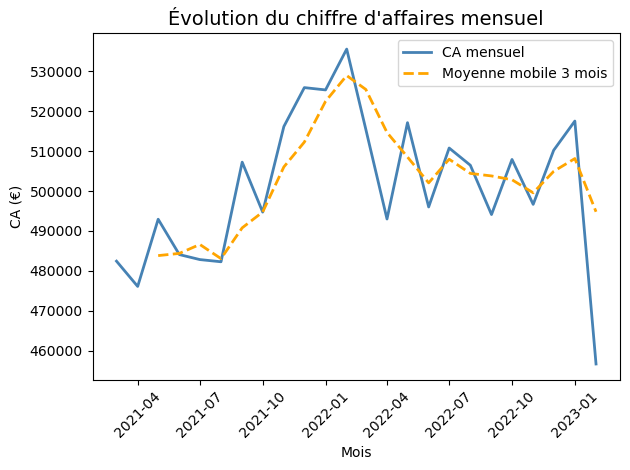

In [27]:
#CA mensuel
ca_mensuel = df_final.groupby('month_year')['price'].sum().reset_index()
ca_mensuel.columns = ['month_year', 'ca']
ca_mensuel['mois_dt'] = ca_mensuel['month_year'].dt.to_timestamp()

display(ca_mensuel.head())

#Moyenne mobile 3 mois
ca_mensuel['Moyenne_mobile'] = ca_mensuel['ca'].rolling(window=3).mean()

#Graphique
fig, ax = plt.subplots()
ax.plot(ca_mensuel['mois_dt'], ca_mensuel['ca'], color='steelblue', linewidth=2, label='CA mensuel')
ax.plot(ca_mensuel['mois_dt'], ca_mensuel['Moyenne_mobile'], color='orange', linewidth=2, linestyle='--', label='Moyenne mobile 3 mois')
ax.set_title("Évolution du chiffre d'affaires mensuel", fontsize=14)
ax.set_xlabel("Mois")
ax.set_ylabel("CA (€)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">4.2 - Chiffre d’affaires par catégorie</h3>
</div>

In [28]:
df_final.head()

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge,month_year,year
0,c_1004,m,1973,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both,2021-03,2021
1,c_1011,f,1999,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both,2022-02,2022
2,c_1011,f,1999,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both,2022-03,2022
3,c_1011,f,1999,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both,2022-04,2022
4,c_1011,f,1999,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both,2023-02,2023


In [29]:
#On groupe par la colonne 'categ' et on fait la somme de 'price'
ca_par_categorie = df_final.groupby('categ')['price'].sum().reset_index()

display(ca_par_categorie)

,categ,price
0,0,4419730.97
1,1,4827657.11
2,2,2780275.02


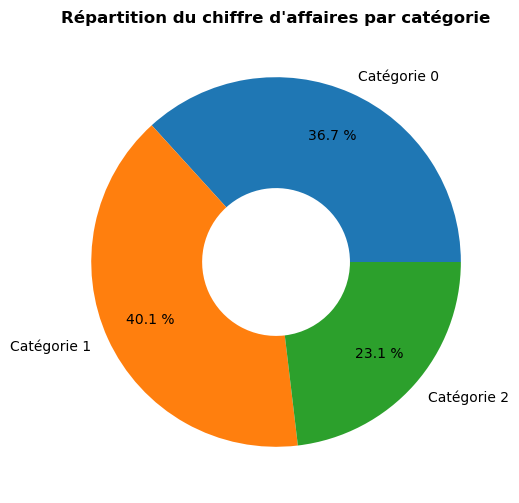

In [30]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    ca_par_categorie.price,
    labels=[ 'Catégorie ' + str(cat) for cat in ca_par_categorie.categ ],
    autopct='%.1f %%',
    pctdistance=0.75,
    wedgeprops=dict(width=0.6)
)

ax.set_title("Répartition du chiffre d'affaires par catégorie", fontsize=12, fontweight='bold')
plt.show()

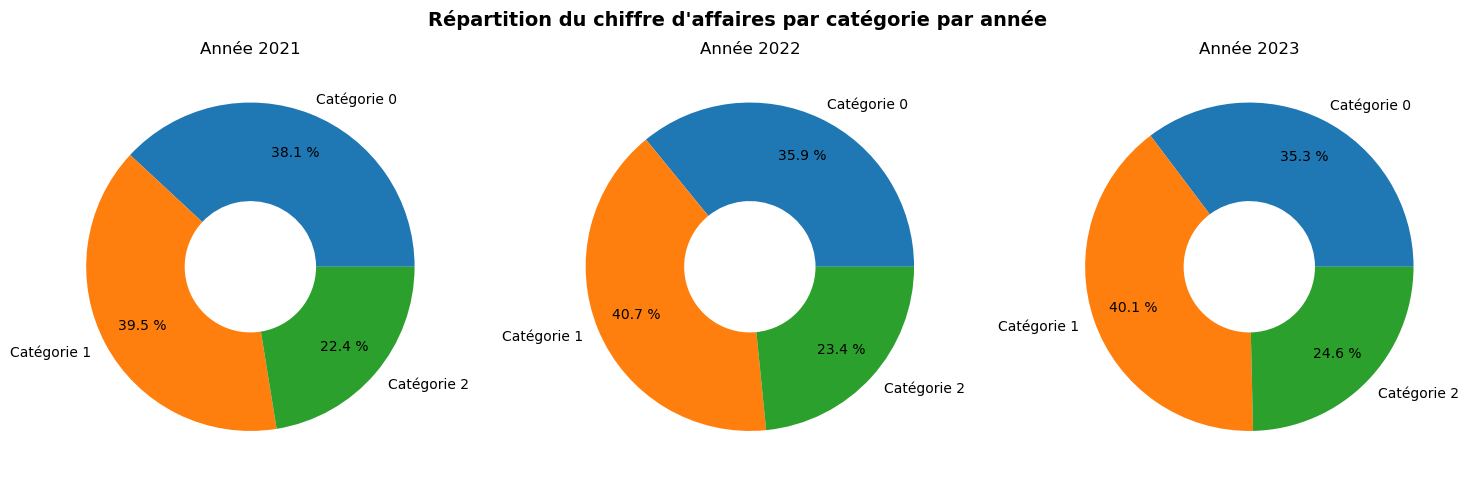

In [31]:
#import matplotlib.pyplot as plt
#import math

annees = sorted(df_final['year'].unique())
nb_annees = len(annees)

# Création d'une grille de graphiques (1 ligne, autant de colonnes que d'années)
fig, axes = plt.subplots(1, nb_annees, figsize=(5 * nb_annees, 5))

# Si vous n'avez qu'une seule année, matplotlib ne retourne pas une liste d'axes
if nb_annees == 1:
    axes = [axes]

# Boucle pour remplir chaque graphique de la grille
for i, annee in enumerate(annees):
    df_annee = df_final[df_final['year'] == annee]
    ca_annee = df_annee.groupby('categ')['price'].sum().reset_index()
    
    ax = axes[i]
    
    ax.pie(
        ca_annee['price'],
        labels=['Catégorie ' + str(cat) for cat in ca_annee['categ']],
        autopct='%.1f %%',
        pctdistance=0.75,
        wedgeprops=dict(width=0.6)
    )
    
    ax.set_title(f"Année {annee}")

plt.suptitle("Répartition du chiffre d'affaires par catégorie par année", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
#Calcul du CA par mois et par catégorie
ca_evol = df_final.groupby(['month_year', 'categ'])['price'].sum().reset_index()
display(ca_evol.head())

#Pivotage pour une lecture plus facile (Analyses chiffrées)
ca_pivot = ca_evol.pivot(index='month_year', columns='categ', values='price').fillna(0)

print("Évolution mensuelle du chiffres d'affaires par catégorie :")
display(ca_pivot.head())

,month_year,categ,price
0,2021-03,0,193629.17
1,2021-03,1,186974.17
2,2021-03,2,101837.27
3,2021-04,0,205222.46
4,2021-04,1,156138.35


Évolution mensuelle du chiffres d'affaires par catégorie :


categ,0,1,2
month_year,,,
2021-03,193629.17,186974.17,101837.27
2021-04,205222.46,156138.35,114748.49
2021-05,196186.72,165893.40,130863.35
2021-06,167943.15,189162.04,126983.37
2021-07,144750.79,188523.27,149561.34


<Figure size 1400x700 with 0 Axes>

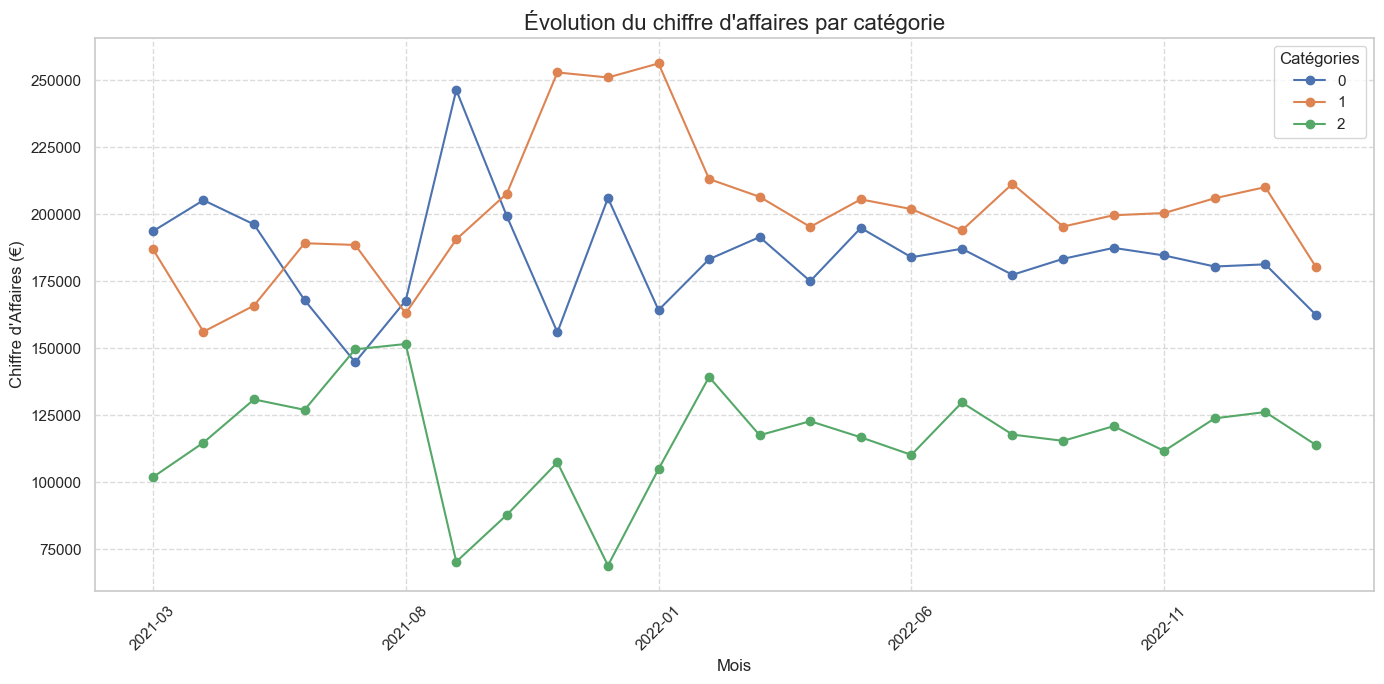

In [33]:
#import matplotlib.pyplot as plt
#import seaborn as sns

# Configuration du style
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

#Tracé des courbes
#On repasse l'index en string pour l'affichage propre des dates sur l'axe X
ca_pivot.index = ca_pivot.index.astype(str)
ca_pivot.plot(kind='line', marker='o', figsize=(14, 7))

#Personnalisation
plt.title("Évolution du chiffre d'affaires par catégorie", fontsize=16)
plt.xlabel("Mois", fontsize=12)
plt.ylabel("Chiffre d'Affaires (€)", fontsize=12)
plt.legend(title="Catégories")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">4.3 - Nombre de clients par mois</h3>
</div>

In [34]:
df_final.head()

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge,month_year,year
0,c_1004,m,1973,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both,2021-03,2021
1,c_1011,f,1999,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both,2022-02,2022
2,c_1011,f,1999,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both,2022-03,2022
3,c_1011,f,1999,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both,2022-04,2022
4,c_1011,f,1999,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both,2023-02,2023


In [35]:
#Calcul du nombre de clients uniques par mois
#On groupe par mois et on compte les valeurs uniques de 'client_id'
nb_clients = df_final.groupby('month_year')['client_id'].nunique().reset_index()
nb_clients.columns = ['Mois', 'Nombre_de_clients']

#Affichage des premières lignes
print("Nombre de clients uniques par mois :")
display(nb_clients)

Nombre de clients uniques par mois :


,Mois,Nombre_de_clients
0,2021-03,5676
1,2021-04,5674
2,2021-05,5644
3,2021-06,5659
4,2021-07,5672
5,2021-08,5642
6,2021-09,5693
7,2021-10,6190
8,2021-11,5875
9,2021-12,5867


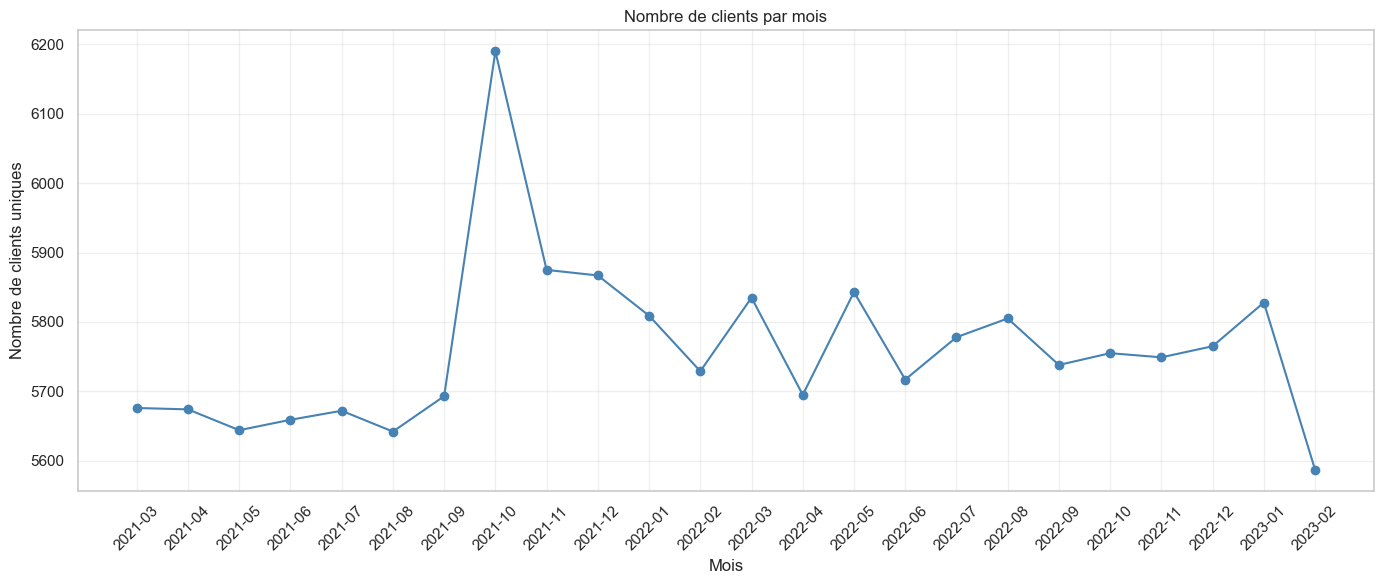

In [36]:
# Calcul uniquement pour les clients
nb_clients = df_final.groupby('month_year')['client_id'].nunique()

# Création du graphique unique
plt.figure(figsize=(14, 6))

plt.plot(
    nb_clients.index.astype(str), 
    nb_clients.values, 
    color='steelblue', 
    marker='o'  # Optionnel : ajoute des points pour plus de lisibilité
)

plt.title("Nombre de clients par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de clients uniques")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">4.4 - Nombre de transactions</h3>
</div>

In [37]:
df_final.head()

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge,month_year,year
0,c_1004,m,1973,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both,2021-03,2021
1,c_1011,f,1999,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both,2022-02,2022
2,c_1011,f,1999,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both,2022-03,2022
3,c_1011,f,1999,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both,2022-04,2022
4,c_1011,f,1999,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both,2023-02,2023


In [38]:
#Calcul des transactions (Paniers uniques)
transactions_mensuelles = df_final.groupby('month_year')['session_id'].nunique().reset_index() #nunique ou count ?
transactions_mensuelles.columns = ['Mois', 'Nombre_de_transactions']

print("Nombre de TRANSACTIONS (paniers uniques) par mois :")
display(transactions_mensuelles)

Nombre de TRANSACTIONS (paniers uniques) par mois :


,Mois,Nombre_de_transactions
0,2021-03,14201
1,2021-04,13970
2,2021-05,14168
3,2021-06,13838
4,2021-07,13571
5,2021-08,13591
6,2021-09,14848
7,2021-10,14781
8,2021-11,14605
9,2021-12,15566


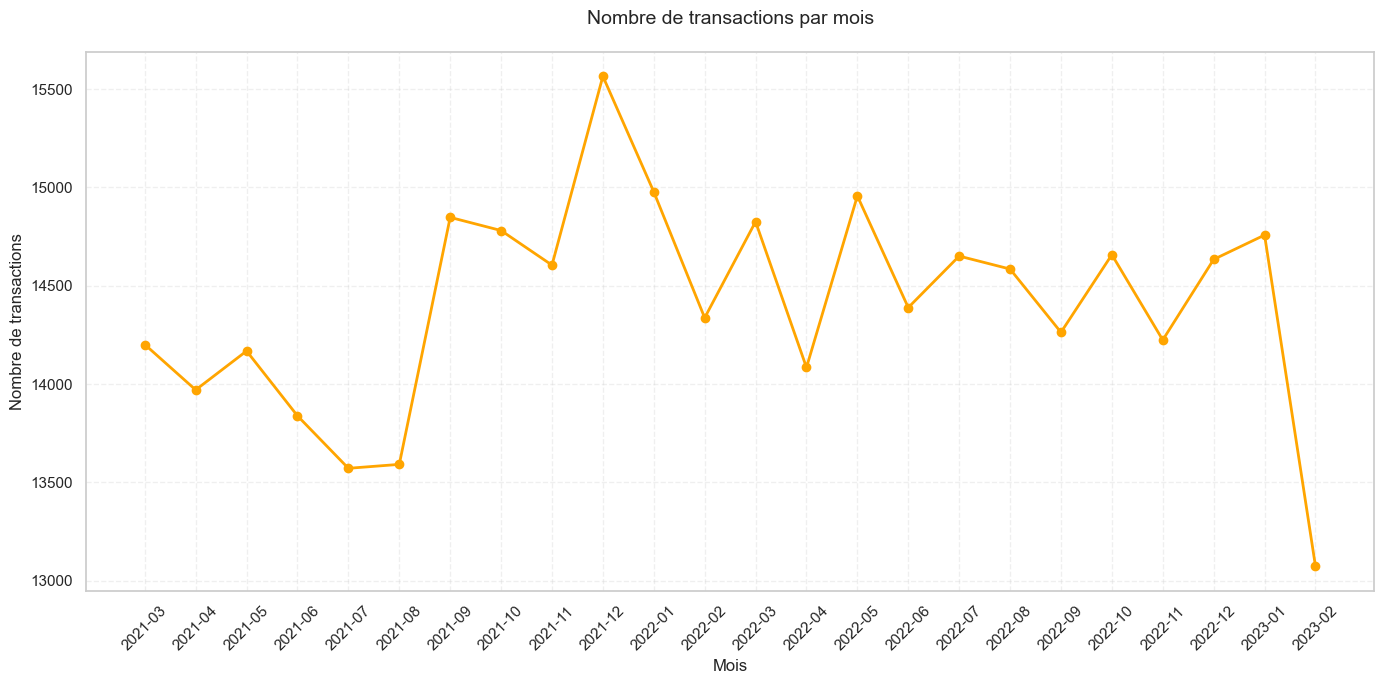

In [39]:
# Calcul uniquement pour les transactions
nb_transactions = df_final.groupby('month_year')['session_id'].nunique()

fig, ax = plt.subplots(figsize=(14, 7))

# Tracé de la ligne
ax.plot(
    nb_transactions.index.astype(str), 
    nb_transactions.values, 
    color='orange', 
    marker='o',
    linewidth=2
)

ax.set_title("Nombre de transactions par mois", fontsize=14, pad=20)
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de transactions")
ax.grid(True, linestyle='--', alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">4.5 - Nombre de produits vendus</h3>
</div>

In [40]:
df_final.head()

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge,month_year,year
0,c_1004,m,1973,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both,2021-03,2021
1,c_1011,f,1999,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both,2022-02,2022
2,c_1011,f,1999,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both,2022-03,2022
3,c_1011,f,1999,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both,2022-04,2022
4,c_1011,f,1999,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both,2023-02,2023


In [41]:
nb_prod_vendu = df_final.groupby(['month_year'])['id_prod'].nunique().reset_index()
nb_prod_vendu.columns = ['Mois', 'Nombre_de_produits_vendus']
display(nb_prod_vendu)

,Mois,Nombre_de_produits_vendus
0,2021-03,2482
1,2021-04,2492
2,2021-05,2471
3,2021-06,2414
4,2021-07,2369
5,2021-08,2404
6,2021-09,2560
7,2021-10,2506
8,2021-11,2432
9,2021-12,2505


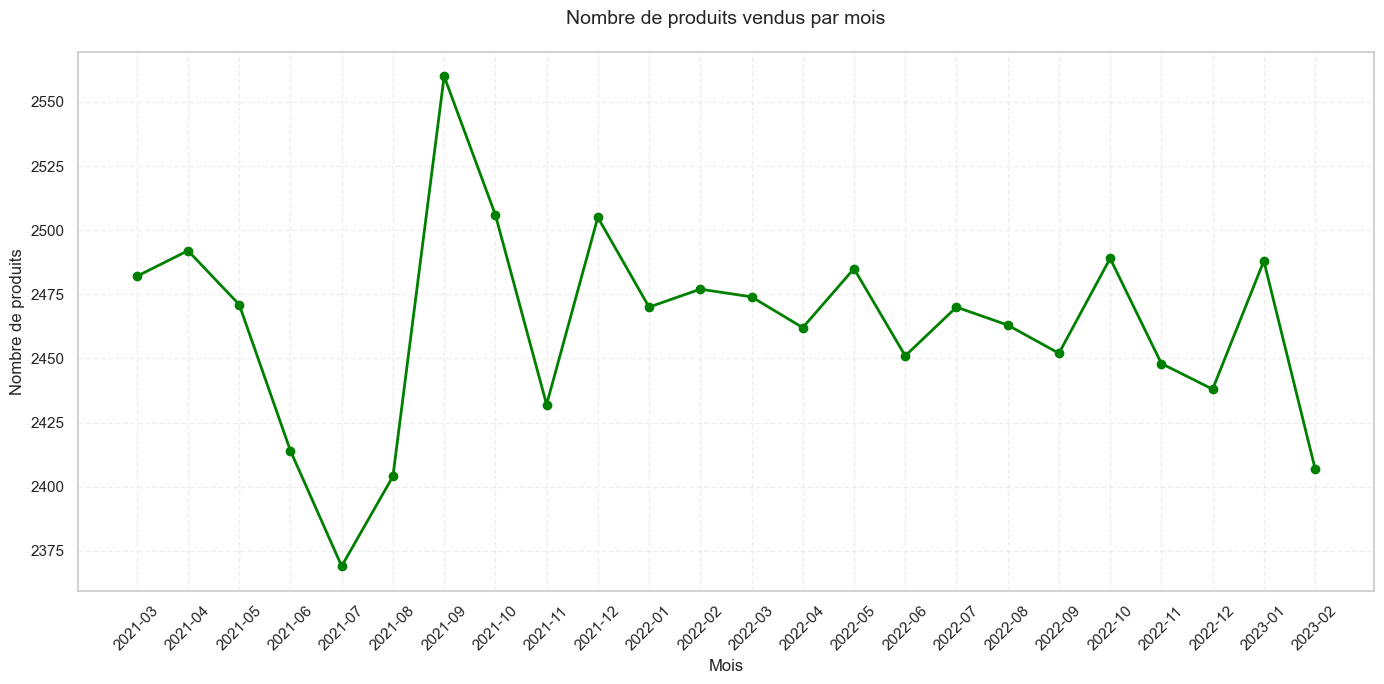

In [42]:
# Calcul uniquement pour les transactions
nb_prod_vendu = df_final.groupby('month_year')['id_prod'].nunique()


fig, ax = plt.subplots(figsize=(14, 7))

# Tracé de la ligne
ax.plot(
    nb_prod_vendu.index.astype(str), 
    nb_prod_vendu.values, 
    color='green', 
    marker='o',
    linewidth=2
)

ax.set_title("Nombre de produits vendus par mois", fontsize=14, pad=20)
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de produits")
ax.grid(True, linestyle='--', alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">4.6 - Les tops</h3>
</div>

In [43]:
df_final.head()

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge,month_year,year
0,c_1004,m,1973,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both,2021-03,2021
1,c_1011,f,1999,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both,2022-02,2022
2,c_1011,f,1999,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both,2022-03,2022
3,c_1011,f,1999,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both,2022-04,2022
4,c_1011,f,1999,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both,2023-02,2023


In [44]:
########################## TOP VENTES ANNUELLES EN MONTANT ##############################

#Somme des prix par produit et par année (on utilise .sum() sur 'price')
top_ventes_ca = df_final.groupby(['year', 'id_prod'])['price'].sum().reset_index(name='ca_total')

#Top 3 des produits avec le plus de CA chaque année
top_3_annuel_ca = top_ventes_ca.sort_values(['year', 'ca_total'], ascending=[True, False])
top_3_annuel_ca = top_3_annuel_ca.groupby('year').head(3)

print("Aperçu des 3 meilleurs produits en montant (CA) par an :")
display(top_3_annuel_ca)

Aperçu des 3 meilleurs produits en montant (CA) par an :


,year,id_prod,ca_total
3086,2021,2_159,39563.29
3060,2021,2_135,27389.03
3036,2021,2_112,26149.59
6309,2022,2_159,47592.74
6283,2022,2_135,36633.69
6259,2022,2_112,32771.45
9120,2023,2_159,7737.47
9076,2023,2_112,6486.72
9067,2023,2_102,6091.42


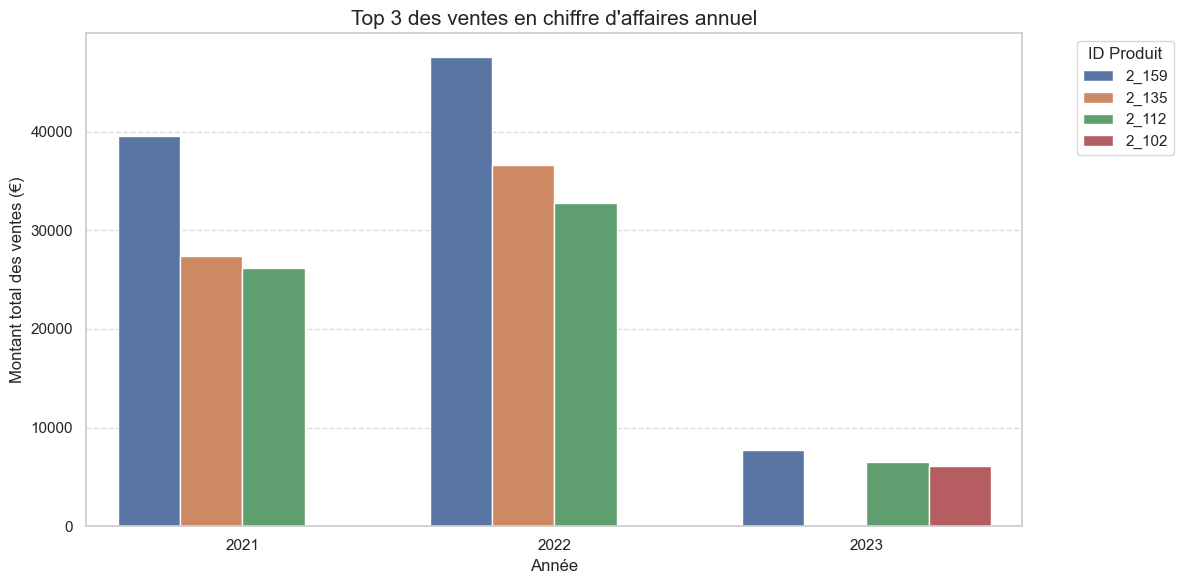

In [45]:
#import matplotlib.pyplot as plt
#import seaborn as sns

#Conversion de l'année en string pour le graphique
top_3_annuel_ca['year_str'] = top_3_annuel_ca['year'].astype(str)

#Taille du graphique
plt.figure(figsize=(12, 6))

#Graphique à barres
sns.barplot(
    data=top_3_annuel_ca, 
    x='year_str', 
    y='ca_total', 
    hue='id_prod'
)

#Titres et axes
plt.title('Top 3 des ventes en chiffre d\'affaires annuel', fontsize=15)
plt.xlabel('Année', fontsize=12)
plt.ylabel('Montant total des ventes (€)', fontsize=12)
plt.legend(title='ID Produit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [46]:
########################## TOP VENTES ANNUELLES EN VOLUME ##############################

#Comptage des ventes par produit et par année
top_ventes_vol = df_final.groupby(['year', 'id_prod']).size().reset_index(name='volume')

#Extraction du Top 3 des produits les plus vendus chaque année
top_3_annuel_vol = top_ventes_vol.sort_values(['year', 'volume'], ascending=[True, False])
top_3_annuel_vol = top_3_annuel_vol.groupby('year').head(3)

print("Aperçu des 3 meilleures ventes en volume par an :")
print(top_3_annuel_vol.head(10))

Aperçu des 3 meilleures ventes en volume par an :
      year id_prod  volume
2582  2021   1_369     935
2635  2021   1_417     912
2632  2021   1_414     881
5806  2022   1_369    1201
5859  2022   1_417    1197
5856  2022   1_414    1162
8657  2023   1_369     204
8702  2023   1_414     203
8700  2023   1_412     179


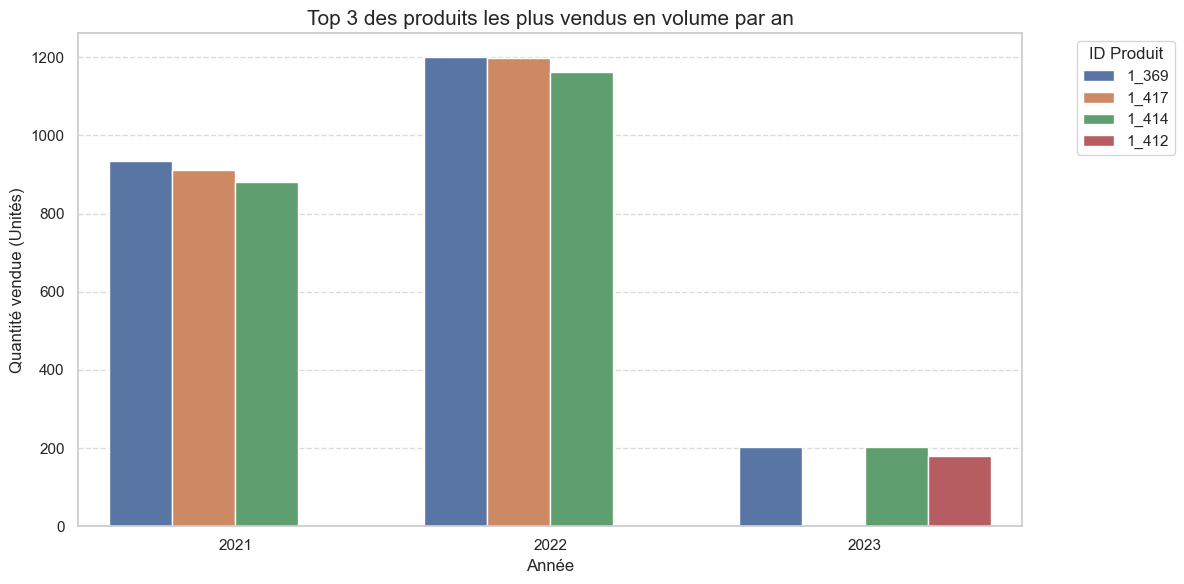

In [47]:
#import matplotlib.pyplot as plt
#import seaborn as sns

#Conversion de l'année en string pour le graphique
top_3_annuel_vol['year_str'] = top_3_annuel_vol['year'].astype(str)

#Taille du graphique
plt.figure(figsize=(12, 6))

#Graphique à barres
sns.barplot(
    data=top_3_annuel_vol, 
    x='year_str', 
    y='volume', 
    hue='id_prod'
)

#Titres et axes
plt.title('Top 3 des produits les plus vendus en volume par an', fontsize=15)
plt.xlabel('Année', fontsize=12)
plt.ylabel('Quantité vendue (Unités)', fontsize=12)  # Changement de l'unité ici
plt.legend(title='ID Produit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [48]:
########################## TOP VENTES GLOBALES EN MONTANT ##############################

#Somme des prix par produit et par année (on utilise .sum() sur 'price')
top_ventes_ca = df_final.groupby(['id_prod'])['price'].sum().reset_index(name='ca_total')

#Top 3 des produits avec le plus de CA chaque année
top_10_annuel_ca = top_ventes_ca.sort_values(['ca_total'], ascending=[False]).head(10)

print("Aperçu des 10 meilleurs produits en montant (CA) par an :")
display(top_10_annuel_ca)

Aperçu des 10 meilleurs produits en montant (CA) par an :


,id_prod,ca_total
3096,2_159,94893.50
3070,2_135,69334.95
3045,2_112,65407.76
3034,2_102,60736.78
3152,2_209,56971.86
2619,1_395,56617.47
2591,1_369,56136.60
3043,2_110,53846.25
2607,1_383,53834.43
2641,1_414,53522.18


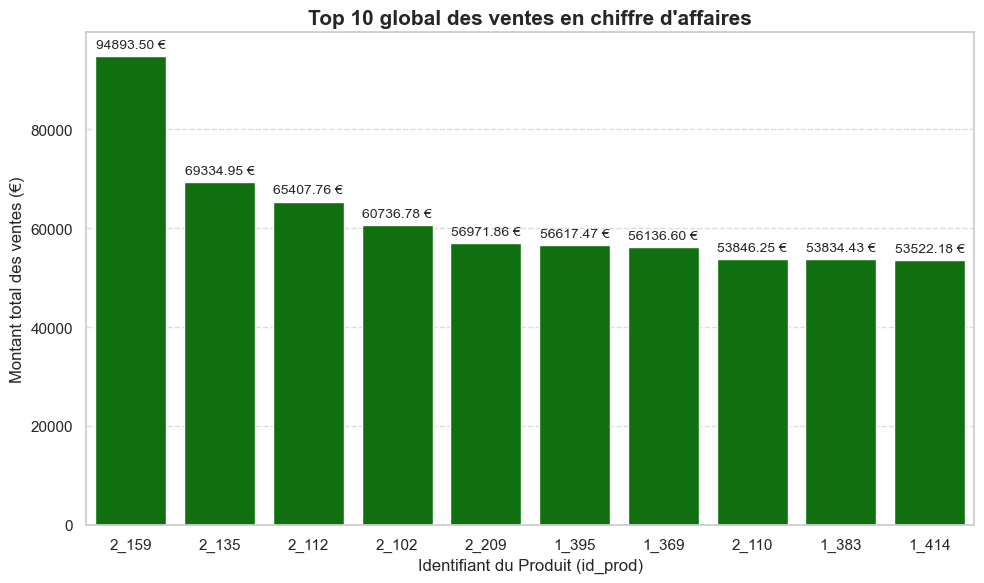

In [49]:
#import matplotlib.pyplot as plt
#import seaborn as sns

#Taille du graphique
plt.figure(figsize=(10, 6))

#Graphique à barres
sns.barplot(
    data=top_10_annuel_ca, 
    x='id_prod', 
    y='ca_total', 
    color='green'
)

#Titres et axes adaptés au global
plt.title("Top 10 global des ventes en chiffre d'affaires", fontsize=15, fontweight='bold')
plt.xlabel('Identifiant du Produit (id_prod)', fontsize=12)
plt.ylabel('Montant total des ventes (€)', fontsize=12)

#Optionnel : Ajout des étiquettes de valeur au-dessus des barres pour plus de précision
for p in plt.gca().patches:
    if p.get_height() > 0: # Évite d'annoter les barres vides s'il y en a
        plt.gca().annotate(f"{p.get_height():.2f} €", 
                            (p.get_x() + p.get_width() / 2., p.get_height()), 
                            ha='center', va='center', 
                            xytext=(0, 8), 
                            textcoords='offset points', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">4.7 - Les flops</h3>
</div>

In [50]:
df_final.head()

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge,month_year,year
0,c_1004,m,1973,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both,2021-03,2021
1,c_1011,f,1999,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both,2022-02,2022
2,c_1011,f,1999,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both,2022-03,2022
3,c_1011,f,1999,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both,2022-04,2022
4,c_1011,f,1999,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both,2023-02,2023


In [51]:
########################## FLOP VENTES GLOBALES EN MONTANT ##############################

#Somme des prix par produit et par année (on utilise .sum() sur 'price')
flop_ventes_ca = df_final.groupby(['id_prod'])['price'].sum().reset_index(name='ca_total')

# 2. On trie du plus petit au plus grand (ascending=True) et on prend les 3 pires (head(3))
flop_3_global_ca = flop_ventes_ca.sort_values(['ca_total'], ascending=[True]).head(10)

print("Aperçu des 3 pires ventes globales en montant (CA) :")
display(flop_3_global_ca)

Aperçu des 3 pires ventes globales en montant (CA) :


,id_prod,ca_total
595,0_1539,0.99
313,0_1284,1.38
719,0_1653,1.98
1784,0_541,1.99
665,0_1601,1.99
2079,0_807,1.99
802,0_1728,2.27
549,0_1498,2.48
2179,0_898,2.54
925,0_1840,2.56


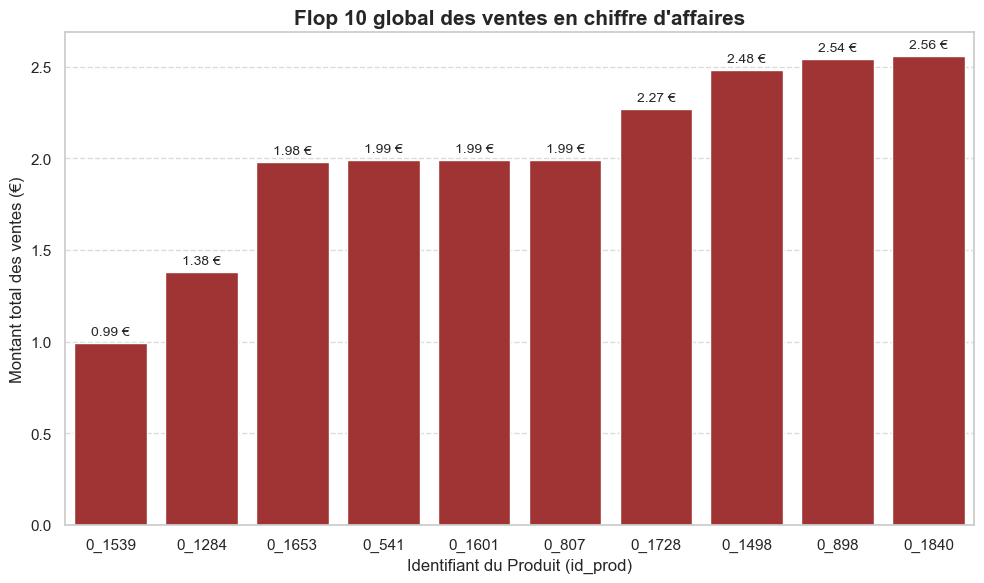

In [52]:
#import matplotlib.pyplot as plt
#import seaborn as sns

#Taille du graphique
plt.figure(figsize=(10, 6))

#Graphique à barres
sns.barplot(
    data=flop_3_global_ca, 
    x='id_prod', 
    y='ca_total', 
    color='firebrick'
)

#Titres et axes adaptés au global
plt.title("Flop 10 global des ventes en chiffre d'affaires", fontsize=15, fontweight='bold')
plt.xlabel('Identifiant du Produit (id_prod)', fontsize=12)
plt.ylabel('Montant total des ventes (€)', fontsize=12)

#Optionnel : Ajout des étiquettes de valeur au-dessus des barres pour plus de précision
for p in plt.gca().patches:
    if p.get_height() > 0: # Évite d'annoter les barres vides s'il y en a
        plt.gca().annotate(f"{p.get_height():.2f} €", 
                            (p.get_x() + p.get_width() / 2., p.get_height()), 
                            ha='center', va='center', 
                            xytext=(0, 8), 
                            textcoords='offset points', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">4.8 - Répartition par catégorie</h3>
</div>

In [53]:
df_final.head()

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge,month_year,year
0,c_1004,m,1973,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both,2021-03,2021
1,c_1011,f,1999,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both,2022-02,2022
2,c_1011,f,1999,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both,2022-03,2022
3,c_1011,f,1999,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both,2022-04,2022
4,c_1011,f,1999,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both,2023-02,2023


In [54]:
#Calcul du montant et de la part de CA par catégorie

#Calcul du montant de CA par catégorie
# on groupe par catégorie et on calcul le CA réalisé pour chaque catégorie
ventes_categ = df_final.groupby('categ')['price'].sum().reset_index()
ventes_categ.columns = ['Catégorie', 'CA réalisé']

#Affichage des premières lignes
print("Montant de CA par catégorie :")
print(ventes_categ.head())

Montant de CA par catégorie :
   Catégorie  CA réalisé
0          0  4419730.97
1          1  4827657.11
2          2  2780275.02


C:\Users\arnme\AppData\Local\Temp\ipykernel_58272\2565681758.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x='Catégorie', y='CA réalisé', data=ventes_categ, palette='viridis')


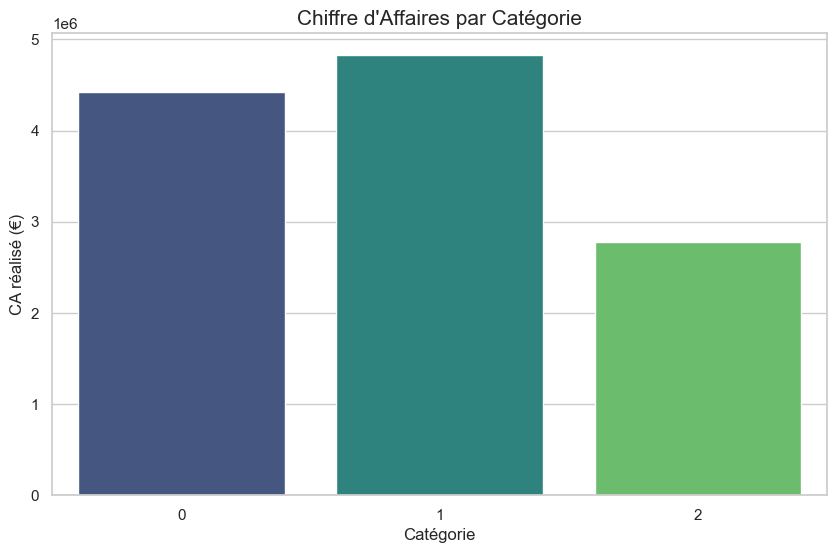

In [55]:
#import matplotlib.pyplot as plt
#import seaborn as sns

# Configuration du style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Création du barplot
plot = sns.barplot(x='Catégorie', y='CA réalisé', data=ventes_categ, palette='viridis')

# Ajout des labels et du titre
plt.title('Chiffre d\'Affaires par Catégorie', fontsize=15)
plt.xlabel('Catégorie', fontsize=12)
plt.ylabel('CA réalisé (€)', fontsize=12)

# Affichage du graphique
plt.show()

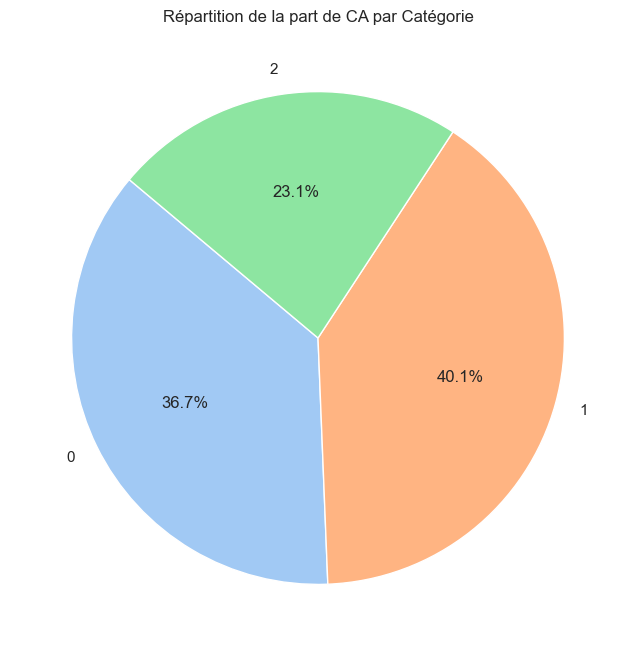

In [56]:
plt.figure(figsize=(8, 8))

plt.pie(ventes_categ['CA réalisé'], 
        labels=ventes_categ['Catégorie'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=sns.color_palette('pastel'))

plt.title('Répartition de la part de CA par Catégorie')
plt.show()

#Graphique pas forcément pertinent car catégorie 0 et 1 très proche

In [57]:
#Vértifier CA total
print(df_final['price'].sum())

12027663.1


<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">4.9 - Répartition du chiffre d'affaires pour les clients BtoB</h3>
</div>

In [58]:
df_final.head()

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge,month_year,year
0,c_1004,m,1973,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both,2021-03,2021
1,c_1011,f,1999,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both,2022-02,2022
2,c_1011,f,1999,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both,2022-03,2022
3,c_1011,f,1999,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both,2022-04,2022
4,c_1011,f,1999,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both,2023-02,2023


In [59]:
#On cherche les plus gros clients
#On identifie les clients effectuant le plus d'achat

ca_client = df_final.groupby('client_id')['price'].sum().reset_index()
ca_client = ca_client.sort_values('price', ascending=False)

print("Aperçu des clients générant le plus de chiffre d'affaires sur la période :")
display(ca_client.head())

Aperçu des clients générant le plus de chiffre d'affaires sur la période :


,client_id,price
677,c_1609,326039.89
4388,c_4958,290227.03
6337,c_6714,153918.60
2724,c_3454,114110.57
634,c_1570,5285.82


On cherche la représentation dans le CA généré des BtoB
On observe que client achète pour plus de  100 000€ de livres
On créée une nouvelle colonne pour catégoriser les types de client 'BtoB' ou 'BtoC'

In [60]:
#Seuil BtoB — on prend les clients au-dessus de 100 000 €
seuil_btob = 100000
btob = ca_client[ca_client['price'] >= seuil_btob]
btoc = ca_client[ca_client['price'] < seuil_btob]

print(f"Clients BtoB identifiés : {len(btob)}")
display(btob)

#CA total BtoB vs BtoC
ca_btob = btob['price'].sum()
ca_btoc = btoc['price'].sum()
ca_total = ca_client['price'].sum()

print(f"\nCA BtoB : {ca_btob:,.0f} € ({ca_btob/ca_total*100:.1f}%)")
print(f"CA BtoC : {ca_btoc:,.0f} € ({ca_btoc/ca_total*100:.1f}%)")

Clients BtoB identifiés : 4


,client_id,price
677,c_1609,326039.89
4388,c_4958,290227.03
6337,c_6714,153918.60
2724,c_3454,114110.57



CA BtoB : 884,296 € (7.4%)
CA BtoC : 11,143,367 € (92.6%)


<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">4.10 - Courbe de Lorenz</h3>
</div>

In [61]:
df_final.head()

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge,month_year,year
0,c_1004,m,1973,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both,2021-03,2021
1,c_1011,f,1999,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both,2022-02,2022
2,c_1011,f,1999,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both,2022-03,2022
3,c_1011,f,1999,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both,2022-04,2022
4,c_1011,f,1999,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both,2023-02,2023


In [62]:
#Liste des clients BtoB à exclure
btob_liste = btob['client_id'].tolist()
print("Clients 'B to B' exclus :", btob_liste)

#Création du dataframe sans les BtoB
df_btoc = df_final[~df_final['client_id'].isin(btob_liste)].copy()

print(f"\nDataframe complet    : {df_final.shape[0]} lignes")
print(f"Dataframe sans BtoB  : {df_btoc.shape[0]} lignes")
print(f"Lignes supprimées    : {df_final.shape[0] - df_btoc.shape[0]}")

display(df_btoc)

#Pour la suite, on travaillera avec la table 'df_btoc'

Clients 'B to B' exclus : ['c_1609', 'c_4958', 'c_6714', 'c_3454']

Dataframe complet    : 687534 lignes
Dataframe sans BtoB  : 640734 lignes
Lignes supprimées    : 46800


,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge,month_year,year
0,c_1004,m,1973,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both,2021-03,2021
1,c_1011,f,1999,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both,2022-02,2022
2,c_1011,f,1999,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both,2022-03,2022
3,c_1011,f,1999,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both,2022-04,2022
4,c_1011,f,1999,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both,2023-02,2023
...,...,...,...,...,...,...,...,...,...,...,...
687550,c_5828,f,1998,2_99,2022-07-21 01:53:46.967570,s_241374,84.99,2,both,2022-07,2022
687551,c_5828,f,1998,2_99,2023-01-21 01:53:46.967570,s_329932,84.99,2,both,2023-01,2023
687552,c_7135,m,1996,2_99,2021-07-11 20:56:49.820935,s_61009,84.99,2,both,2021-07,2021
687553,c_7135,m,1996,2_99,2022-11-11 20:56:49.820935,s_296127,84.99,2,both,2022-11,2022


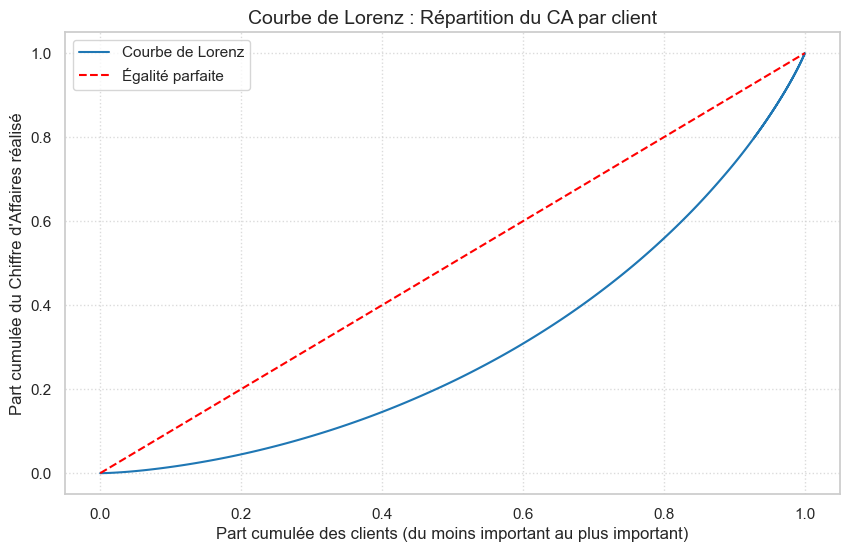

Indice de Gini : 0.398


In [63]:
#import numpy as np
#import matplotlib.pyplot as plt

#Calcul du CA par client
#On utilise df_final qui contient déjà les prix
ca_client = df_btoc.groupby('client_id')['price'].sum().values

#Préparation des données pour Lorenz
#On trie les montants par ordre croissant
lorenz = np.sort(ca_client)
#Calcul de la part cumulée (on divise chaque étape par la somme totale)
lorenz = np.cumsum(lorenz) / lorenz.sum()
#On ajoute un point 0 au début pour que la courbe parte de l'origine
lorenz = np.append([0], lorenz)

#Création de l'axe X (part cumulée de la population de 0 à 1)
xaxis = np.linspace(0, 1, len(lorenz))

#Graphique
plt.figure(figsize=(10, 6))

#Courbe de Lorenz
plt.plot(xaxis, lorenz, drawstyle='steps-post', color='#1f77b4', label='Courbe de Lorenz')

#Tracé de la ligne d'égalité parfaite (diagonale)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Égalité parfaite')

#Personnalisation
plt.title('Courbe de Lorenz : Répartition du CA par client', fontsize=14)
plt.xlabel('Part cumulée des clients (du moins important au plus important)')
plt.ylabel('Part cumulée du Chiffre d\'Affaires réalisé')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.show()

#Calcul de l'indice de Gini
#Aire sous la courbe de Lorenz
auc = np.trapezoid(lorenz, xaxis)

#Formule du Gini
gini = (0.5 - auc) / 0.5
print(f"Indice de Gini : {gini:.3f}")

<div style="background-color: RGB(150, 20, 30);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyses - Julie</h2>
</div>

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">5.1 - Lien entre le genre d’un client et les catégories des livres
achetés</h3>
</div>

In [64]:
df_btoc.head()

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge,month_year,year
0,c_1004,m,1973,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both,2021-03,2021
1,c_1011,f,1999,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both,2022-02,2022
2,c_1011,f,1999,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both,2022-03,2022
3,c_1011,f,1999,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both,2022-04,2022
4,c_1011,f,1999,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both,2023-02,2023


In [65]:
#quali-quali => chi-2 ou fisher

In [66]:
from scipy.stats import chi2_contingency

#Préparation des données — une ligne par client
clients = df_btoc.groupby('client_id').agg(
    sex=('sex', 'first'),
    categ_principale=('categ', lambda x: x.mode()[0])
).reset_index()

#Tableau de contingence
contingency_table = pd.crosstab(clients['sex'], clients['categ_principale'])
print("Tableau de contingence :")
display(contingency_table)

#Test Chi²
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi² : {chi2:.4f}")
print(f"p-value : {p:.4f}")
print(f"Degrés de liberté : {dof}")
print(f"\nEffectifs théoriques (min) : {expected.min():.1f} → condition ≥ 5 : {'✅' if expected.min() >= 5 else '❌'}")

# Interprétation
if p < 0.05:
    print(f"\n p-value < 0.05 → On rejette H0")
    print("→ Il existe un lien significatif entre le genre et la catégorie achetée.")
else:
    print(f"\n p-value > 0.05 → On ne rejette pas H0")
    print("→ Pas de lien significatif entre le genre et la catégorie achetée.")

Tableau de contingence :


categ_principale,0,1,2
sex,,,
f,2370,1608,500
m,2256,1385,477



Chi² : 4.8977
p-value : 0.0864
Degrés de liberté : 2

Effectifs théoriques (min) : 468.0 → condition ≥ 5 : ✅

 p-value > 0.05 → On ne rejette pas H0
→ Pas de lien significatif entre le genre et la catégorie achetée.


In [67]:
clients.head()

,client_id,sex,categ_principale
0,c_1,m,0
1,c_10,m,1
2,c_100,m,1
3,c_1000,f,1
4,c_1001,m,0


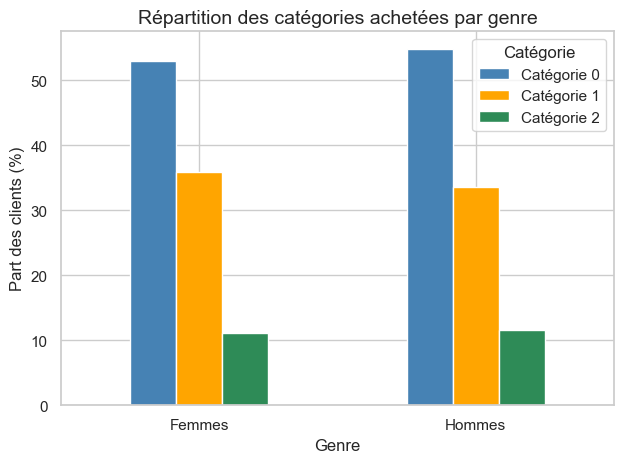

In [68]:
# Graphique bivarié — répartition des catégories par genre
client_profile_pct = clients.groupby('sex')['categ_principale'].value_counts(normalize=True).unstack() * 100

fig, ax = plt.subplots()
client_profile_pct.plot(kind='bar', ax=ax, color=['steelblue','orange','seagreen'], 
                        width=0.5, edgecolor='white')

ax.set_title("Répartition des catégories achetées par genre", fontsize=14)
ax.set_xlabel("Genre")
ax.set_ylabel("Part des clients (%)")
ax.set_xticklabels(['Femmes', 'Hommes'], rotation=0)
ax.legend(title='Catégorie', labels=['Catégorie 0', 'Catégorie 1', 'Catégorie 2'])
plt.tight_layout()
plt.show()

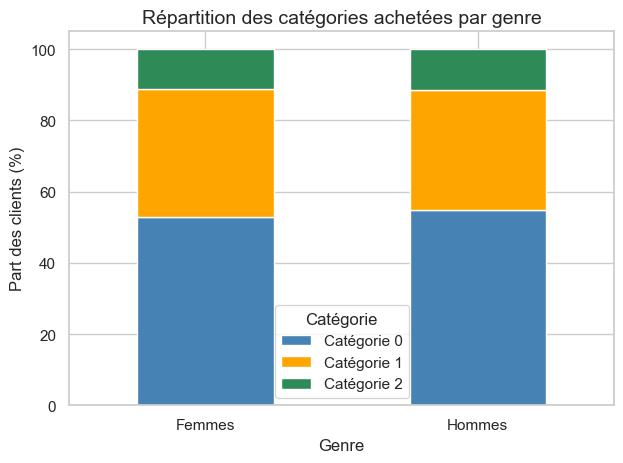

In [69]:
# Graphique bivarié — répartition des catégories par genre
client_profile_pct = clients.groupby('sex')['categ_principale'].value_counts(normalize=True).unstack() * 100

fig, ax = plt.subplots()
client_profile_pct.plot(kind='bar', ax=ax, color=['steelblue','orange','seagreen'], 
                        width=0.5, edgecolor='white', stacked=True) # <-- Ajout de stacked=True

ax.set_title("Répartition des catégories achetées par genre", fontsize=14)
ax.set_xlabel("Genre")
ax.set_ylabel("Part des clients (%)")
ax.set_xticklabels(['Femmes', 'Hommes'], rotation=0)
ax.legend(title='Catégorie', labels=['Catégorie 0', 'Catégorie 1', 'Catégorie 2'])
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">5.2 - Lien entre l'âge des clients et le montant total des achats (Spearman)</h3>
</div>

In [70]:
#quanti - quanti => Pearson (distri normale) ou Spearman (distri non normale)

In [71]:
df_btoc.head()

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge,month_year,year
0,c_1004,m,1973,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both,2021-03,2021
1,c_1011,f,1999,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both,2022-02,2022
2,c_1011,f,1999,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both,2022-03,2022
3,c_1011,f,1999,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both,2022-04,2022
4,c_1011,f,1999,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both,2023-02,2023


In [72]:
# Création colonne avec âge des clients
df_btoc['age'] = df_btoc['date'].dt.year - df_final['birth']

df_btoc.head()

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge,month_year,year,age
0,c_1004,m,1973,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both,2021-03,2021,48.0
1,c_1011,f,1999,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both,2022-02,2022,23.0
2,c_1011,f,1999,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both,2022-03,2022,23.0
3,c_1011,f,1999,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both,2022-04,2022,23.0
4,c_1011,f,1999,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both,2023-02,2023,24.0


In [73]:
# Agréger par client
clients = df_btoc.groupby('client_id').agg(
    age=('age', 'first'),
    montant_total=('price', 'sum'),
).reset_index()

print(f"✅ Données agrégées : {len(clients):,} clients")
display(clients.head())

✅ Données agrégées : 8,596 clients


,client_id,age,montant_total
0,c_1,66.0,629.02
1,c_10,65.0,1353.60
2,c_100,29.0,254.85
3,c_1000,56.0,2291.88
4,c_1001,39.0,1823.85


In [74]:
# DISTRTIBUTION NORMALE OU PAS ? TEST DE SHAPIRO-WILK

import pandas as pd
from scipy.stats import shapiro

# Effectuer le test de Shapiro-Wilk
stat_age, p_value_age = shapiro(clients['age'].sample(5000, random_state=42))
stat_montant_achats, p_value_montant = shapiro(clients['montant_total'].sample(5000, random_state=42))

alpha = 0.05

# Interprétation des résultats variable 'age'
print("========== TEST DE NORMALITÉ DE LA VARIABLE 'age' ==========")
print(f"Statistique du test de Shapiro-Wilk : {stat_age:.4f}")
print(f"Valeur p : {p_value_age:.4f}")

if p_value_age > alpha:
    print("Les données suivent une distribution normale (on ne rejette pas H0)")
else:
    print("Les données ne suivent pas une distribution normale (on rejette H0)")
    print()

# Interprétation des résultats variable 'montant_achat'
print("========== TEST DE NORMALITÉ DE LA VARIABLE 'montant_achats' ==========")
print(f"Statistique du test de Shapiro-Wilk : {stat_montant_achats:.4f}")
print(f"Valeur p : {p_value_montant:.4f}")

if p_value_montant > alpha:
    print("Les données suivent une distribution normale (on ne rejette pas H0)")
else:
    print("Les données ne suivent pas une distribution normale (on rejette H0)")
print()

# Quel test utiliser ?
print('========== QUEL TEST STATISTIQUE UTILISER ==========')
if p_value_age > alpha and p_value_montant > alpha:
    print("Les deux variables sont des distributions normales donc on utilise PEARSON")
else:
    print("Au moins une des variables n'est pas une distribution normale donc on utilise SPEARMAN")

========== TEST DE NORMALITÉ DE LA VARIABLE 'age' ==========
Statistique du test de Shapiro-Wilk : 0.9702
Valeur p : 0.0000
Les données ne suivent pas une distribution normale (on rejette H0)

========== TEST DE NORMALITÉ DE LA VARIABLE 'montant_achats' ==========
Statistique du test de Shapiro-Wilk : 0.9061
Valeur p : 0.0000
Les données ne suivent pas une distribution normale (on rejette H0)

========== QUEL TEST STATISTIQUE UTILISER ==========
Au moins une des variables n'est pas une distribution normale donc on utilise SPEARMAN


In [75]:
from scipy.stats import spearmanr

# Test Spearman
corr, p_spearman = spearmanr(clients['age'], clients['montant_total'])
print(f"\n=== Spearman ===")
print(f"Coefficient ρ : {corr:.4f}")
print(f"p-value       : {p_spearman:.4f}")

if p_spearman < 0.05:
    print("\n✅ p-value < 0.05 → Corrélation significative")
    print(f"→ Lien {'positif' if corr > 0 else 'négatif'} entre l'âge et le montant total des achats.")
else:
    print("\n❌ p-value > 0.05 → Pas de corrélation significative")
    print("→ On ne peut pas conclure à un lien significatif entre l'âge et le montant total des achats.")


=== Spearman ===
Coefficient ρ : -0.1845
p-value       : 0.0000

✅ p-value < 0.05 → Corrélation significative
→ Lien négatif entre l'âge et le montant total des achats.


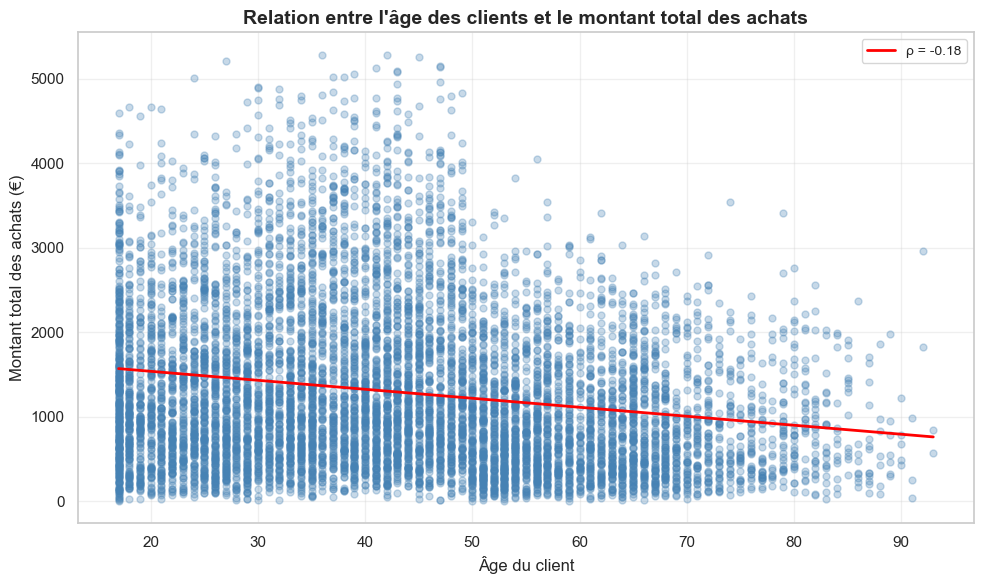

In [76]:
fig, ax = plt.subplots(figsize=(10, 6))

# Nuage de points
ax.scatter(clients['age'], clients['montant_total'],
           alpha=0.3, s=25, color='steelblue')

# Calcul de la droite de tendance
z = np.polyfit(clients['age'], clients['montant_total'], 1)
p = np.poly1d(z)
x_line = np.linspace(clients['age'].min(), clients['age'].max(), 100)

# Tracé de la droite avec le coefficient
ax.plot(x_line, p(x_line), color='red', linewidth=2, label=f'ρ = {corr:.2f}')

# Titres et mise en forme
ax.set_title("Relation entre l'âge des clients et le montant total des achats", fontsize=14, fontweight='bold')
ax.set_xlabel("Âge du client")
ax.set_ylabel("Montant total des achats (€)")
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">5.3 - Lien entre l'âge des clients et la fréquence d’achat</h3>
</div>

In [77]:
#quanti-quanti => Pearson ou Spearman

In [78]:
df_btoc.head()

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge,month_year,year,age
0,c_1004,m,1973,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both,2021-03,2021,48.0
1,c_1011,f,1999,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both,2022-02,2022,23.0
2,c_1011,f,1999,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both,2022-03,2022,23.0
3,c_1011,f,1999,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both,2022-04,2022,23.0
4,c_1011,f,1999,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both,2023-02,2023,24.0


In [79]:
# DISTRTIBUTION NORMALE OU PAS ? TEST DE SHAPIRO-WILK

import pandas as pd
from scipy.stats import shapiro

# Extraire la colonne 'age'
clients = df_btoc.groupby('client_id').agg(
    age=('age', 'first'),
    frequence=('session_id', 'count')
).reset_index()

display(clients.head())

# Effectuer le test de Shapiro-Wilk
stat_age, p_value_age = shapiro(clients['age'].sample(5000, random_state=42))
stat_frequence_achats, p_value_freq = shapiro(clients['frequence'].sample(5000, random_state=42))

alpha = 0.05

# Interprétation des résultats variable 'age'
print("========== TEST DE NORMALITÉ DE LA VARIABLE 'age' ==========")
print(f"Statistique du test de Shapiro-Wilk : {stat_age:.4f}")
print(f"Valeur p : {p_value_age:.4f}")

if p_value_age > alpha:
    print("Les données suivent une distribution normale (on ne rejette pas H0)")
else:
    print("Les données ne suivent pas une distribution normale (on rejette H0)")
    print()

# Interprétation des résultats variable 'frequence'
print("========== TEST DE NORMALITÉ DE LA VARIABLE 'frequence' ==========")
print(f"Statistique du test de Shapiro-Wilk : {stat_frequence_achats:.4f}")
print(f"Valeur p : {p_value_freq:.4f}")

if p_value_freq > alpha:
    print("Les données suivent une distribution normale (on ne rejette pas H0)")
else:
    print("Les données ne suivent pas une distribution normale (on rejette H0)")
print()

# Quel test utiliser ?
print('========== QUEL TEST STATISTIQUE UTILISER ==========')
if p_value_age > alpha and p_value_freq > alpha:
    print("Les deux variables sont des distributions normales donc on utilise PEARSON")
else:
    print("Au moins une des variables n'est pas une distribution normale donc on utilise SPEARMAN")

,client_id,age,frequence
0,c_1,66.0,43
1,c_10,65.0,58
2,c_100,29.0,8
3,c_1000,56.0,126
4,c_1001,39.0,103


========== TEST DE NORMALITÉ DE LA VARIABLE 'age' ==========
Statistique du test de Shapiro-Wilk : 0.9702
Valeur p : 0.0000
Les données ne suivent pas une distribution normale (on rejette H0)

========== TEST DE NORMALITÉ DE LA VARIABLE 'frequence' ==========
Statistique du test de Shapiro-Wilk : 0.8167
Valeur p : 0.0000
Les données ne suivent pas une distribution normale (on rejette H0)

========== QUEL TEST STATISTIQUE UTILISER ==========
Au moins une des variables n'est pas une distribution normale donc on utilise SPEARMAN


In [80]:
from scipy.stats import spearmanr

# Test Spearman
corr, p_spearman = spearmanr(clients['age'], clients['frequence'])
print(f"\n=== Spearman ===")
print(f"Coefficient ρ : {corr:.4f}")
print(f"p-value       : {p_spearman:.4f}")

if p_spearman < 0.05:
    print("\n✅ p-value < 0.05 → Corrélation significative")
    print(f"→ Lien {'positif' if corr > 0 else 'négatif'} entre l'âge et le nombre de transactions.")
else:
    print("\n❌ p-value > 0.05 → Pas de corrélation significative")
    print("→ On ne peut pas conclure à un lien significatif entre l'âge et le nombre de transactions.")


=== Spearman ===
Coefficient ρ : 0.1277
p-value       : 0.0000

✅ p-value < 0.05 → Corrélation significative
→ Lien positif entre l'âge et le nombre de transactions.


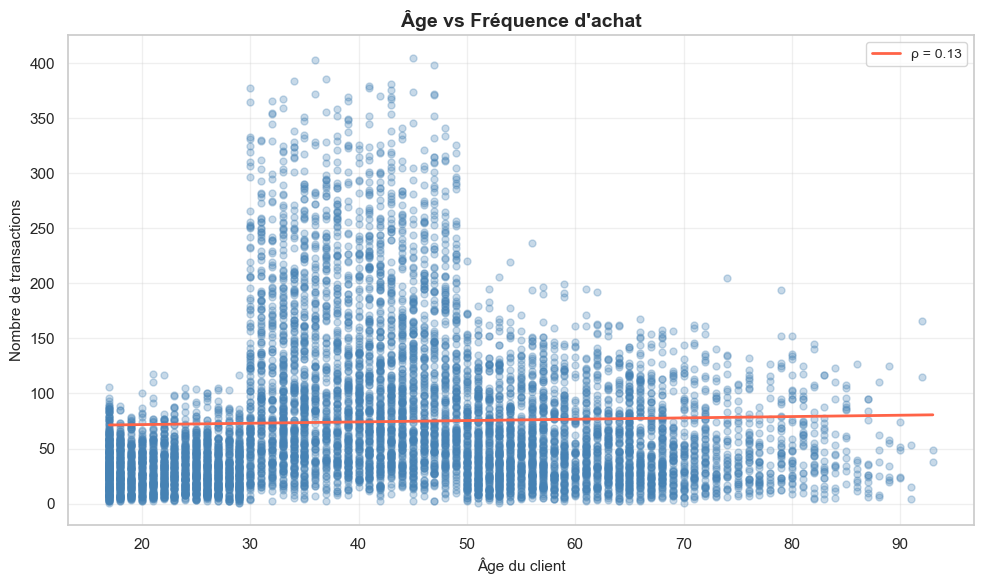

In [81]:
fig, ax = plt.subplots(figsize=(10, 6))

# Nuage de points
ax.scatter(clients['age'], clients['frequence'],
           alpha=0.3, s=25, color='steelblue')

# 2. Calcul de la droite de tendance
z = np.polyfit(clients['age'], clients['frequence'], 1)
p = np.poly1d(z)
x_line = np.linspace(clients['age'].min(), clients['age'].max(), 100)

# Tracé de la droite avec le coefficient
ax.plot(x_line, p(x_line), color='tomato', linewidth=2, label=f'ρ = {corr:.2f}')

# 4. Titres et mise en forme (Syntaxe ax.set_... uniforme)
ax.set_title("Âge vs Fréquence d'achat", fontsize=14, fontweight='bold')
ax.set_xlabel("Âge du client", fontsize=11)
ax.set_ylabel("Nombre de transactions", fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">5.4 - Lien entre l'âge des clients et la taille du panier moyen</h3>
</div>

In [82]:
#quanti-quanti => Pearson ou spearman

In [83]:
# DISTRTIBUTION NORMALE OU PAS ? TEST DE SHAPIRO-WILK

#Agrégation et calcul des variables par client
clients = df_btoc.groupby('client_id').agg(
    age=('age', 'first'), 
    montant_total=('price', 'sum'), 
    frequence=('session_id', 'count')
).reset_index()

clients['panier_moyen'] = clients['montant_total'] / clients['frequence']

display(clients.head())

# Effectuer le test de Shapiro-Wilk (Échantillon de 5000 clients cohérent)
stat_age, p_value_age = shapiro(clients['age'].sample(5000, random_state=42))
stat_panier_moyen, p_panier_moyen = shapiro(clients['panier_moyen'].sample(5000, random_state=42))

alpha = 0.05

# Interprétation des résultats de la variable 'age'
print("========== TEST DE NORMALITÉ DE LA VARIABLE 'age' ==========")
print(f"Statistique du test de Shapiro-Wilk : {stat_age:.4f}")
print(f"Valeur p : {p_value_age:.4f}")

if p_value_age > alpha:
    print("Les données suivent une distribution normale (on ne rejette pas H0)")
else:
    print("Les données ne suivent pas une distribution normale (on rejette H0)")
print()

# Interprétation des résultats de la variable 'panier_moyen'
print("========== TEST DE NORMALITÉ DE LA VARIABLE 'panier_moyen' ==========")
print(f"Statistique du test de Shapiro-Wilk : {stat_panier_moyen:.4f}")
print(f"Valeur p : {p_panier_moyen:.4f}")

if p_panier_moyen > alpha:
    print("Les données suivent une distribution normale (on ne rejette pas H0)")
else:
    print("Les données ne suivent pas une distribution normale (on rejette H0)")
print()

# Quel test utiliser ?
print('========== QUEL TEST STATISTIQUE UTILISER ==========')
if p_value_age > alpha and p_panier_moyen > alpha:
    print("Les deux variables sont des distributions normales donc on utilise PEARSON")
else:
    print("Au moins une des variables n'est pas une distribution normale donc on utilise SPEARMAN")

,client_id,age,montant_total,frequence,panier_moyen
0,c_1,66.0,629.02,43,14.628372
1,c_10,65.0,1353.60,58,23.337931
2,c_100,29.0,254.85,8,31.856250
3,c_1000,56.0,2291.88,126,18.189524
4,c_1001,39.0,1823.85,103,17.707282


========== TEST DE NORMALITÉ DE LA VARIABLE 'age' ==========
Statistique du test de Shapiro-Wilk : 0.9702
Valeur p : 0.0000
Les données ne suivent pas une distribution normale (on rejette H0)

========== TEST DE NORMALITÉ DE LA VARIABLE 'panier_moyen' ==========
Statistique du test de Shapiro-Wilk : 0.6828
Valeur p : 0.0000
Les données ne suivent pas une distribution normale (on rejette H0)

========== QUEL TEST STATISTIQUE UTILISER ==========
Au moins une des variables n'est pas une distribution normale donc on utilise SPEARMAN


In [84]:
from scipy.stats import spearmanr

# Test Spearman
corr, p_spearman = spearmanr(clients['age'], clients['panier_moyen'])

print(f"\n=== Spearman ===")
print(f"Coefficient ρ : {corr:.4f}")
print(f"p-value       : {p_spearman:.4f}")

if p_spearman < 0.05:
    print("\n✅ p-value < 0.05 → Corrélation significative")
    print(f"→ Lien {'positif' if corr > 0 else 'négatif'} entre l'âge et la taille du panier moyen.")
else:
    print("\n❌ p-value > 0.05 → Pas de corrélation significative")
    print("→ On ne peut pas conclure à un lien significatif entre l'âge et la taille du panier moyen.")


=== Spearman ===
Coefficient ρ : -0.3257
p-value       : 0.0000

✅ p-value < 0.05 → Corrélation significative
→ Lien négatif entre l'âge et la taille du panier moyen.


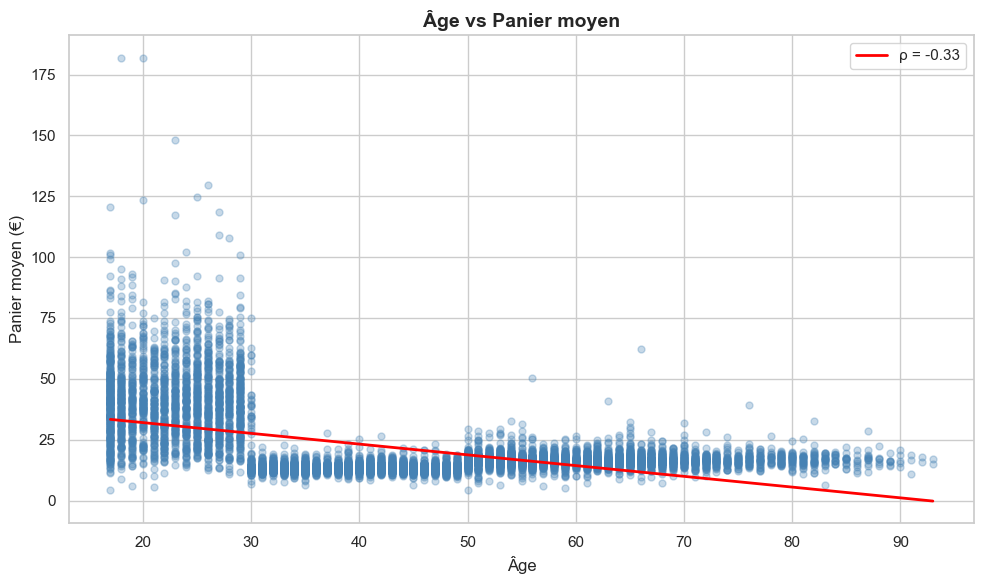

In [85]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(clients['age'], clients['panier_moyen'],
           alpha=0.3, s=25, color='steelblue')

z = np.polyfit(clients['age'], clients['panier_moyen'], 1)
p = np.poly1d(z)
x_line = np.linspace(clients['age'].min(), clients['age'].max(), 100)
ax.plot(x_line, p(x_line), color='red', linewidth=2, label=f'ρ = {corr:.2f}')

ax.set_title("Âge vs Panier moyen", fontsize=14, fontweight='bold')
ax.set_xlabel("Âge")
ax.set_ylabel("Panier moyen (€)")
ax.legend()
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">5.5 - Lien entre l'âge des clients et la catégorie des livres achetés</h3>
</div>

In [86]:
#quanti-quali => ANOVA

In [87]:
df_btoc.head()

,client_id,sex,birth,id_prod,date,session_id,price,categ,_merge,month_year,year,age
0,c_1004,m,1973,0_0,2021-03-02 21:57:33.862118,s_908,3.75,0,both,2021-03,2021,48.0
1,c_1011,f,1999,0_0,2022-02-18 16:40:10.068303,s_167174,3.75,0,both,2022-02,2022,23.0
2,c_1011,f,1999,0_0,2022-03-18 16:40:10.068303,s_180968,3.75,0,both,2022-03,2022,23.0
3,c_1011,f,1999,0_0,2022-04-18 16:40:10.068303,s_195932,3.75,0,both,2022-04,2022,23.0
4,c_1011,f,1999,0_0,2023-02-18 16:40:10.068303,s_343439,3.75,0,both,2023-02,2023,24.0


In [88]:
from scipy.stats import f_oneway, levene, kruskal, shapiro

# Âge moyen par catégorie principale achetée
clients = df_btoc.groupby('client_id').agg(
    age=('age', 'first'),
    categ_principale=('categ', lambda x: x.mode()[0])
).reset_index()

display(clients.head())

# Groupes
groupe_0 = clients[clients['categ_principale'] == 0]['age']
groupe_1 = clients[clients['categ_principale'] == 1]['age']
groupe_2 = clients[clients['categ_principale'] == 2]['age']

print("=== Statistiques par groupe ===")
for g, nom in zip([groupe_0, groupe_1, groupe_2], ['Catégorie 0', 'Catégorie 1', 'Catégorie 2']):
    print(f"{nom} : n={len(g)}, moyenne={g.mean():.1f} ans, std={g.std():.1f}")

# Shapiro-Wilk par groupe
print(f"\n=== Shapiro-Wilk par groupe ===")
for g, nom in zip([groupe_0, groupe_1, groupe_2], ['Catégorie 0', 'Catégorie 1', 'Catégorie 2']):
    stat, p = shapiro(g.sample(min(5000, len(g)), random_state=42))
    print(f"{nom} : p={p:.4f} → {'normale ✅' if p > 0.05 else 'non-normale ❌'}")

# Levene
stat_lev, p_lev = levene(groupe_0, groupe_1, groupe_2)
print(f"\n=== Levene ===")
print(f"stat={stat_lev:.4f}, p={p_lev:.4f} → {'variances égales ✅' if p_lev > 0.05 else 'variances inégales ⚠️'}")

# Kruskal-Wallis
stat_k, p_kruskal = kruskal(groupe_0, groupe_1, groupe_2)
print(f"\n=== Kruskal-Wallis ===")
print(f"H = {stat_k:.4f}, p = {p_kruskal:.4f}")
if p_kruskal < 0.05:
    print("✅ p < 0.05 → Différence significative entre les groupes")
else:
    print("❌ p > 0.05 → Pas de différence significative")

# ANOVA à titre indicatif
stat_f, p_anova = f_oneway(groupe_0, groupe_1, groupe_2)
print(f"\n=== ANOVA (à titre indicatif) ===")
print(f"F = {stat_f:.4f}, p = {p_anova:.4f}")


,client_id,age,categ_principale
0,c_1,66.0,0
1,c_10,65.0,1
2,c_100,29.0,1
3,c_1000,56.0,1
4,c_1001,39.0,0


=== Statistiques par groupe ===
Catégorie 0 : n=4626, moyenne=42.7 ans, std=12.5
Catégorie 1 : n=2993, moyenne=49.8 ans, std=19.8
Catégorie 2 : n=977, moyenne=22.8 ans, std=4.3

=== Shapiro-Wilk par groupe ===
Catégorie 0 : p=0.0000 → non-normale ❌
Catégorie 1 : p=0.0000 → non-normale ❌
Catégorie 2 : p=0.0000 → non-normale ❌

=== Levene ===
stat=708.4614, p=0.0000 → variances inégales ⚠️

=== Kruskal-Wallis ===
H = 2003.0188, p = 0.0000
✅ p < 0.05 → Différence significative entre les groupes

=== ANOVA (à titre indicatif) ===
F = 1200.8478, p = 0.0000


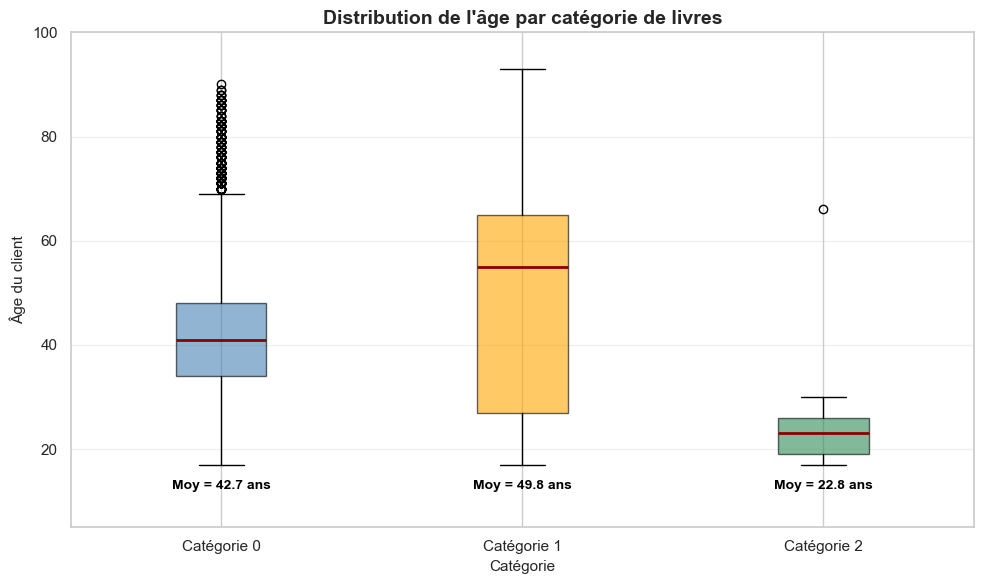

In [89]:
fig, ax = plt.subplots(figsize=(10, 6))

data_plot = [groupe_0, groupe_1, groupe_2]
bp = ax.boxplot(data_plot, tick_labels=['Catégorie 0', 'Catégorie 1', 'Catégorie 2'],
                patch_artist=True)

# Application des couleurs personnalisées
colors = ['steelblue', 'orange', 'seagreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Personnalisation de la ligne de médiane
for median in bp['medians']:
    median.set(color='darkred', linewidth=2)

# Titres et labels
ax.set_title("Distribution de l'âge par catégorie de livres", fontsize=14, fontweight='bold')
ax.set_xlabel("Catégorie", fontsize=11)
ax.set_ylabel("Âge du client", fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

# MODIFICATION : Placement des moyennes sous le minimum (moustache basse)
for i, g in enumerate(data_plot):
    # bp['whiskers'] contient 2 éléments par boîte. La moustache basse est aux indices pairs (0, 2, 4)
    # .get_ydata()[1] nous donne l'extrémité de cette moustache (le minimum)
    bottom_whisker_y = bp['whiskers'][2 * i].get_ydata()[1]
    
    # On place le texte 3 ans en dessous du minimum pour laisser un espace propre
    ax.text(i + 1, bottom_whisker_y - 3, f'Moy = {g.mean():.1f} ans', 
            ha='center', va='top', fontsize=10, fontweight='bold', color='black')

# On ajuste les limites de l'axe Y pour donner de l'espace en bas (ex: minimum à 5 ans au lieu de 10-15)
ax.set_ylim(bottom=5, top=100)

plt.tight_layout()
plt.show()

In [90]:
print("FIN DE L'ÉTUDE ✅")

FIN DE L'ÉTUDE ✅
